# 라이브러리 세팅 및 데이터 세팅

In [1]:
## 기본 라이브러리 세팅
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

plt.rc("font", family ="AppleGothic")

plt.rcParams['axes.unicode_minus'] = False

### 데이터 출처

[Moro et al., 2014] S. Moro, P. Cortez and P. Rita. A Data-Driven Approach to Predict the Success of Bank Telemarketing. Decision Support Systems, In press, [http://dx.doi.org/10.1016/j.dss.2014.03.001]

In [2]:
## 데이터 세팅
## 데이터 원본 링크 : https://archive.ics.uci.edu/dataset/222/bank+marketing

bank_df = pd.read_csv('bank-additional-full.csv', sep=';', encoding="cp949")

# 은행 마케팅 데이터셋 설명 (Bank Marketing Dataset)
2. 기본 정보
제목: 은행 마케팅 (사회/경제적 맥락 포함)

제작자: Sérgio Moro, Paulo Cortez, Paulo Rita (2014년)

데이터 규모:

    * 1. bank-additional-full.csv: 전체 데이터 (41,188개 샘플) 
    * 2. bank-additional.csv: 전체의 10%를 무작위 추출한 데이터 (4,119개 샘플, SVM 등 고성능 계산이 필요한 알고리즘 테스트용)

3. 주요 특징
본 데이터셋은 기존 UCI "Bank Marketing" 데이터를 기반으로 하되, 5가지의 사회/경제적 지표가 추가되었습니다.
분석 결과, 이 5가지 경제 지표를 추가했을 때 마케팅 성공 여부(정기 예금 가입) 예측력이 크게 향상되었습니다.
**분석 목표: 고객이 정기 예금(Term Deposit)에 가입할 것인지(y) 예측하는 이진 분류(Binary Classification) 문제입니다.**

4. 속성 정보 (Attribute Information)
[고객 관련 데이터]
* age: 나이 (수치형)
* job: 직업 유형 (범주형: "admin.", "blue-collar", "entrepreneur", "housemaid", "management", "retired", "self-employed", "services", "student", "technician", "unemployed", "unknown")
* marital: 결혼 상태 (범주형: "divorced", "married", "single", "unknown". 참고: "divorced"는 이혼 및 사별 포함)
* education: 교육 수준 (범주형: "basic.4y", "basic.6y", "basic.9y", "high.school", "illiterate", "professional.course", "university.degree", "unknown")
* default: 채무 불이행 여부 (범주형: "no", "yes", "unknown")
* housing: 주택 담보 대출 여부 (범주형: "no", "yes", "unknown")
* loan: 개인 대출 여부 (범주형: "no", "yes", "unknown")

[마지막 접촉 관련 데이터]
* contact: 연락 수단 (범주형: "cellular", "telephone")  => cellular 1, telephone 0
* month: 마지막 연락 월 (범주형: "jan", "feb", "mar", ..., "nov", "dec")
* day_of_week: 마지막 연락 요일 (범주형: "mon", "tue", "wed", "thu", "fri")
* duration: 마지막 통화 시간(초) (수치형).
    **주의: 이 변수는 예측 결과에 매우 큰 영향을 미칩니다 (예: 0초면 가입 안 함). 하지만 통화가 끝나기 전에는 알 수 없는 정보이므로, 실제 예측 모델을 구축할 때는 이 변수를 제외하는 것이 현실적입니다.**

[기타 속성]
* campaign: 이번 캠페인 동안 해당 고객에게 연락한 횟수 (수치형)
* pdays: 이전 캠페인 마지막 연락 후 경과일 (수치형; 999는 이전 연락 없음 의미)
* previous: 이번 캠페인 이전에 해당 고객에게 연락한 횟수 (수치형)
* poutcome: 이전 마케팅 캠페인의 결과 (범주형: "failure", "nonexistent", "success")

[사회/경제적 지표]

* emp.var.rate: 고용 변동률 - 분기별 지표 (수치형)
* cons.price.idx: 소비자 물가 지수 - 월별 지표 (수치형)
* cons.conf.idx: 소비자 신뢰 지수 - 월별 지표 (수치형)
* euribor3m: 유리보(Euribor) 3개월 금리 - 일별 지표 (수치형)
* nr.employed: 종사자 수 - 분기별 지표 (수치형)

[타겟 변수 (Output)]
y: 고객의 정기 예금 가입 여부 (이진 범주형: "yes", "no")

5. 결측치 처리 (Missing Values)
일부 범주형 데이터에는 결측치가 존재하며, 모두 **"unknown"**이라는 라벨로 표시되어 있습니다.

이 "unknown" 라벨을 하나의 독립된 클래스로 취급하거나, 삭제 또는 대체(Imputation) 기법을 사용하여 처리할 수 있습니다.

## 데이터 전처리

In [3]:
# 데이터 셋 설명에 따른 제거 선작업.
bank_df.drop(columns=["duration"], inplace=True)

In [4]:
bank_df.shape

(41188, 20)

In [5]:
bank_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  campaign        41188 non-null  int64  
 11  pdays           41188 non-null  int64  
 12  previous        41188 non-null  int64  
 13  poutcome        41188 non-null  object 
 14  emp.var.rate    41188 non-null  float64
 15  cons.price.idx  41188 non-null  float64
 16  cons.conf.idx   41188 non-null  float64
 17  euribor3m       41188 non-null 

### 결측치 처리

In [6]:
bank_df.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [7]:
(bank_df == "unknown").sum()

## 해당 데이터를 삭제하는 것보다는 unknown을 하나의 독립적인 라벨 (모름) 으로 해석하여 진행

age                  0
job                330
marital             80
education         1731
default           8597
housing            990
loan               990
contact              0
month                0
day_of_week          0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64

### 이상치 처리

In [8]:
bank_df.describe(include="object")

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


In [9]:
bank_df.describe()

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [10]:
bank_df[bank_df["pdays"] != 999]
#  pdays: 이전 캠페인 마지막 연락 후 경과일 (수치형; 999는 이전 연락 없음 의미)
# 41188건 중 1500건을 제외하고서는 전부 연락 없음 => 데이터 해석에 있어서 1500개는 정보 밀도가 낮다고 판단 => 범주형으로 변환

bank_df["contact_history"] = np.where(
    bank_df["pdays"] != 999,
    "contact",
    "non_contact"
)

bank_df.drop(columns=["pdays"], inplace=True)

In [11]:
bank_df.describe()

,age,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,2.567593,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,2.770014,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,1.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,1.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,2.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,3.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,56.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


### 중복값 처리

In [12]:
bank_df.duplicated().sum()

bank_df.drop_duplicates(inplace=True)

bank_df.duplicated().sum()

np.int64(0)

In [13]:
bank_df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,contact_history
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,non_contact
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,non_contact
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,non_contact
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,non_contact
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,non_contact
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,1,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes,non_contact
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,1,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no,non_contact
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,2,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no,non_contact
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,1,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes,non_contact


## EDA

In [14]:
numeric_list = bank_df.select_dtypes(include="number").columns.tolist() 
print('numeric col:', numeric_list)

categorical_list = bank_df.select_dtypes(include="object").columns.tolist()  
print('categorica col:', categorical_list)

numeric col: ['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
categorica col: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y', 'contact_history']


numeric col: ['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


categorica col: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y', 'contact_history']

In [15]:
plt.rcParams['figure.figsize'] = (20, 5)

campaign , yes, no

<Axes: xlabel='campaign', ylabel='Density'>

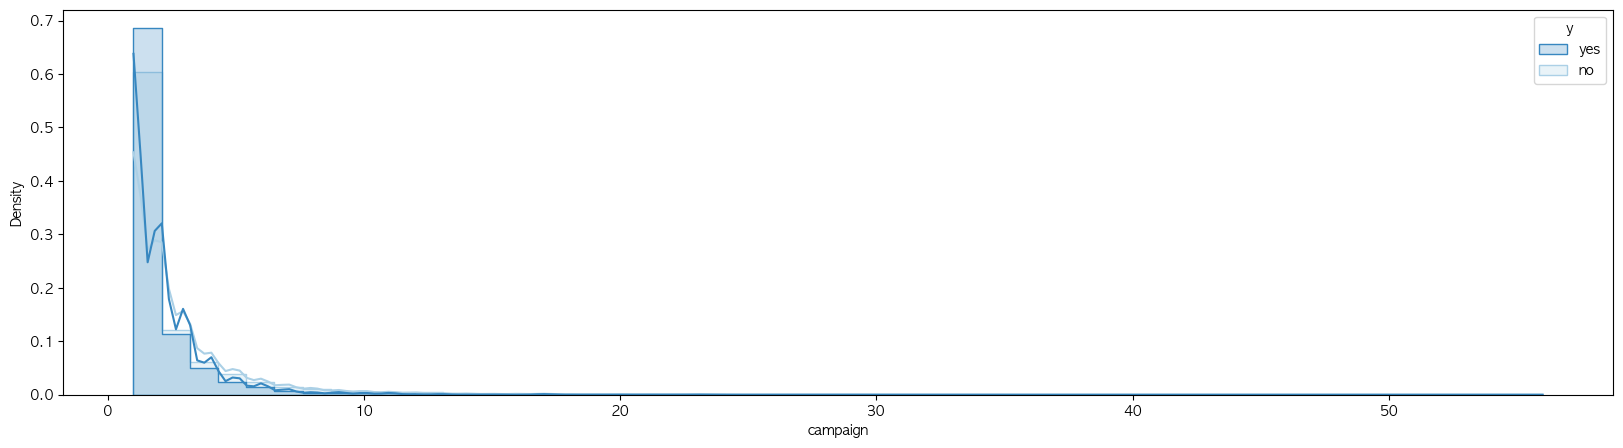

In [16]:
sns.histplot(data=bank_df, x='campaign', hue='y',
             common_norm=False, kde=True, stat='density', bins=50, element='step',
             hue_order=['yes', 'no'], palette='Blues_r')


In [17]:
bank_df[bank_df["poutcome"] == "nonexistent"]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,contact_history
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,non_contact
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,non_contact
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,non_contact
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,non_contact
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,non_contact
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41181,37,admin.,married,university.degree,no,yes,no,cellular,nov,fri,1,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes,non_contact
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,1,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes,non_contact
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,1,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no,non_contact
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,2,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no,non_contact


<Axes: xlabel='age', ylabel='Density'>

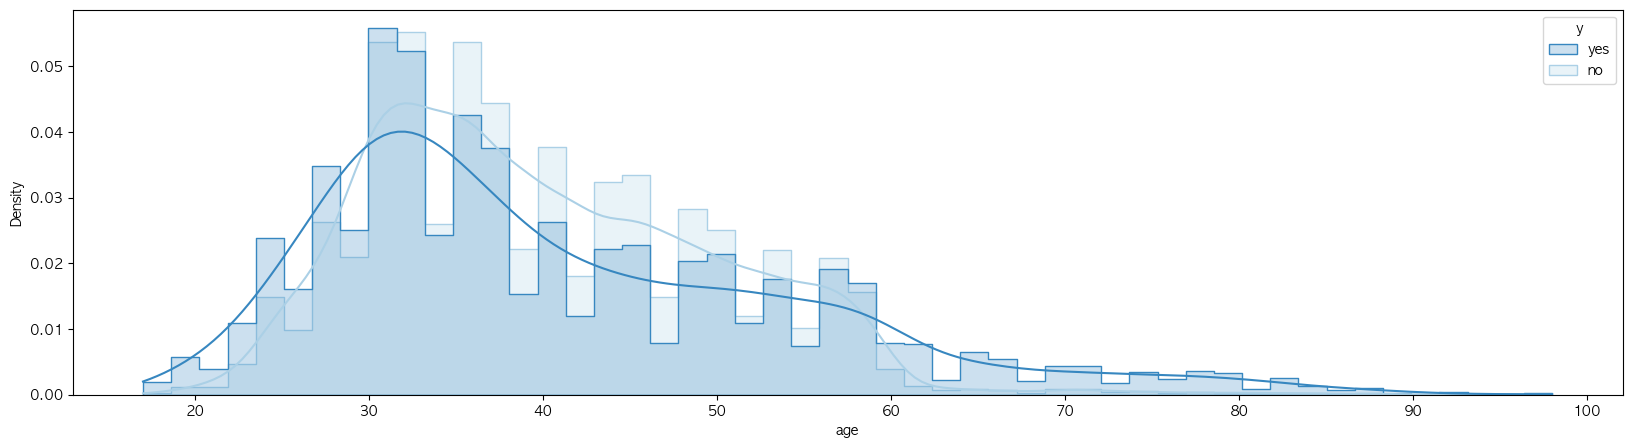

In [18]:
sns.histplot(data=bank_df, x='age', hue='y',
             common_norm=False, kde=True, stat='density', bins=50, element='step',
             hue_order=['yes', 'no'], palette='Blues_r')


categorica col: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y', 'contact_history']


In [19]:
categorical_list.remove("y")

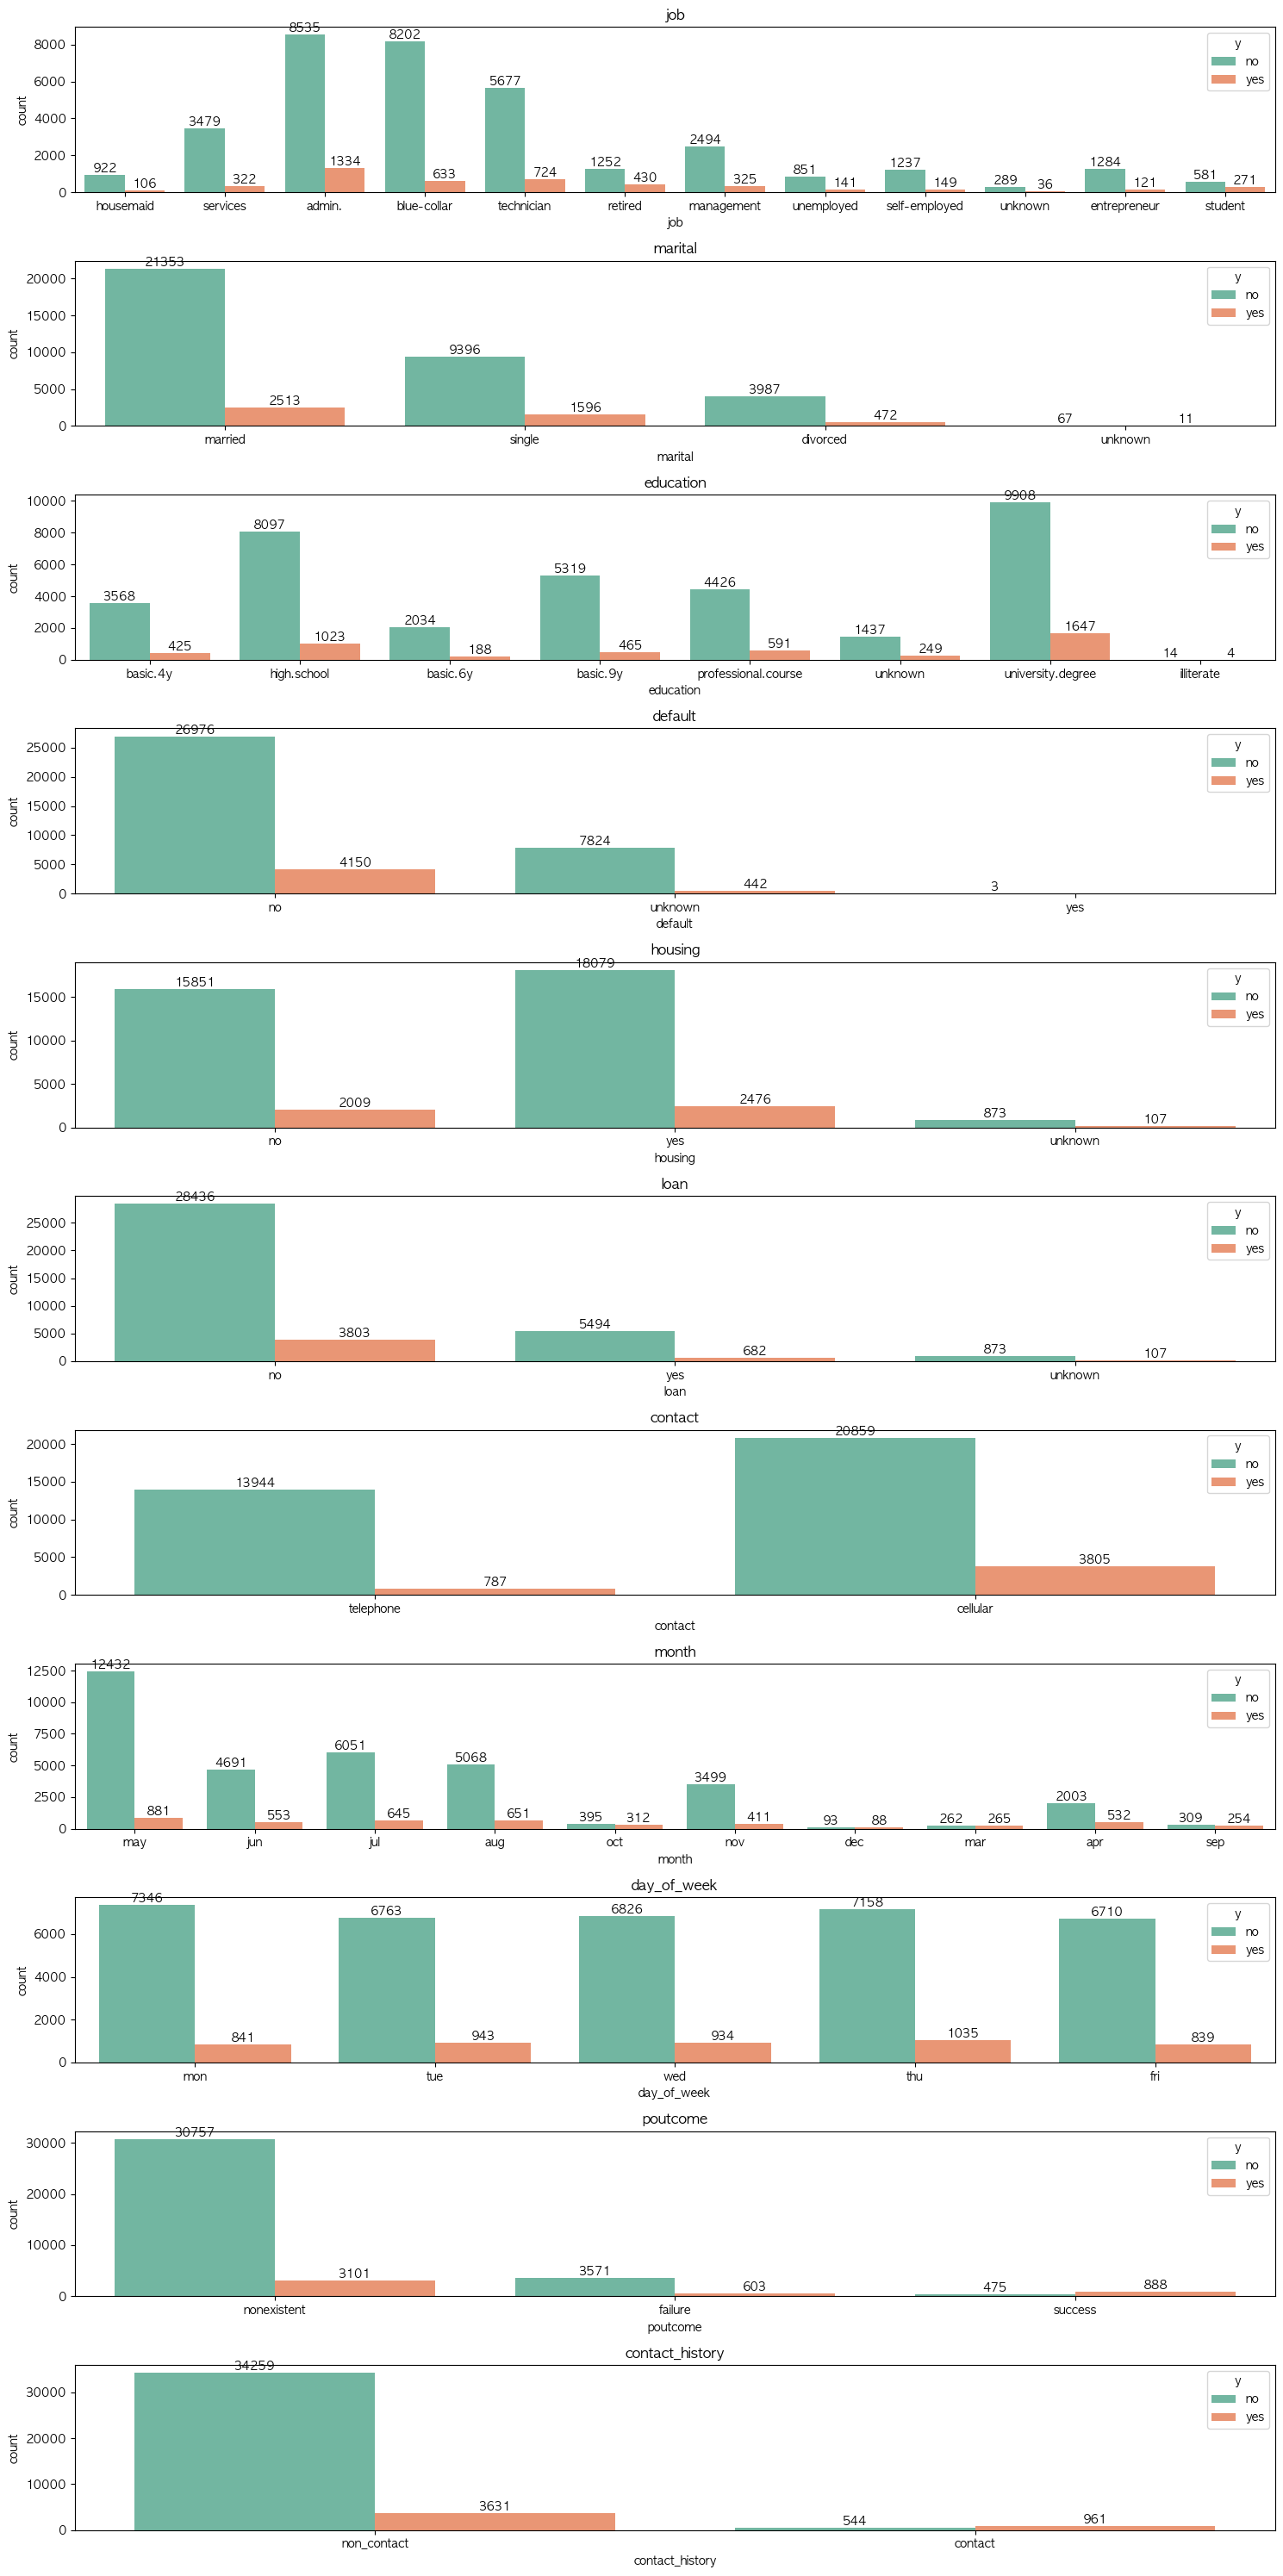

In [20]:
fig, axes = plt.subplots(11, 1, figsize=(15,30))  
axes = axes.flatten()

for ax, categorical in zip(axes, categorical_list):
    sns.countplot(bank_df, x=categorical, hue='y', palette="Set2", ax=ax)
    ax.set_title(categorical)

    for c in ax.containers:
        ax.bar_label(c, fmt='%d')


plt.tight_layout()
plt.show()



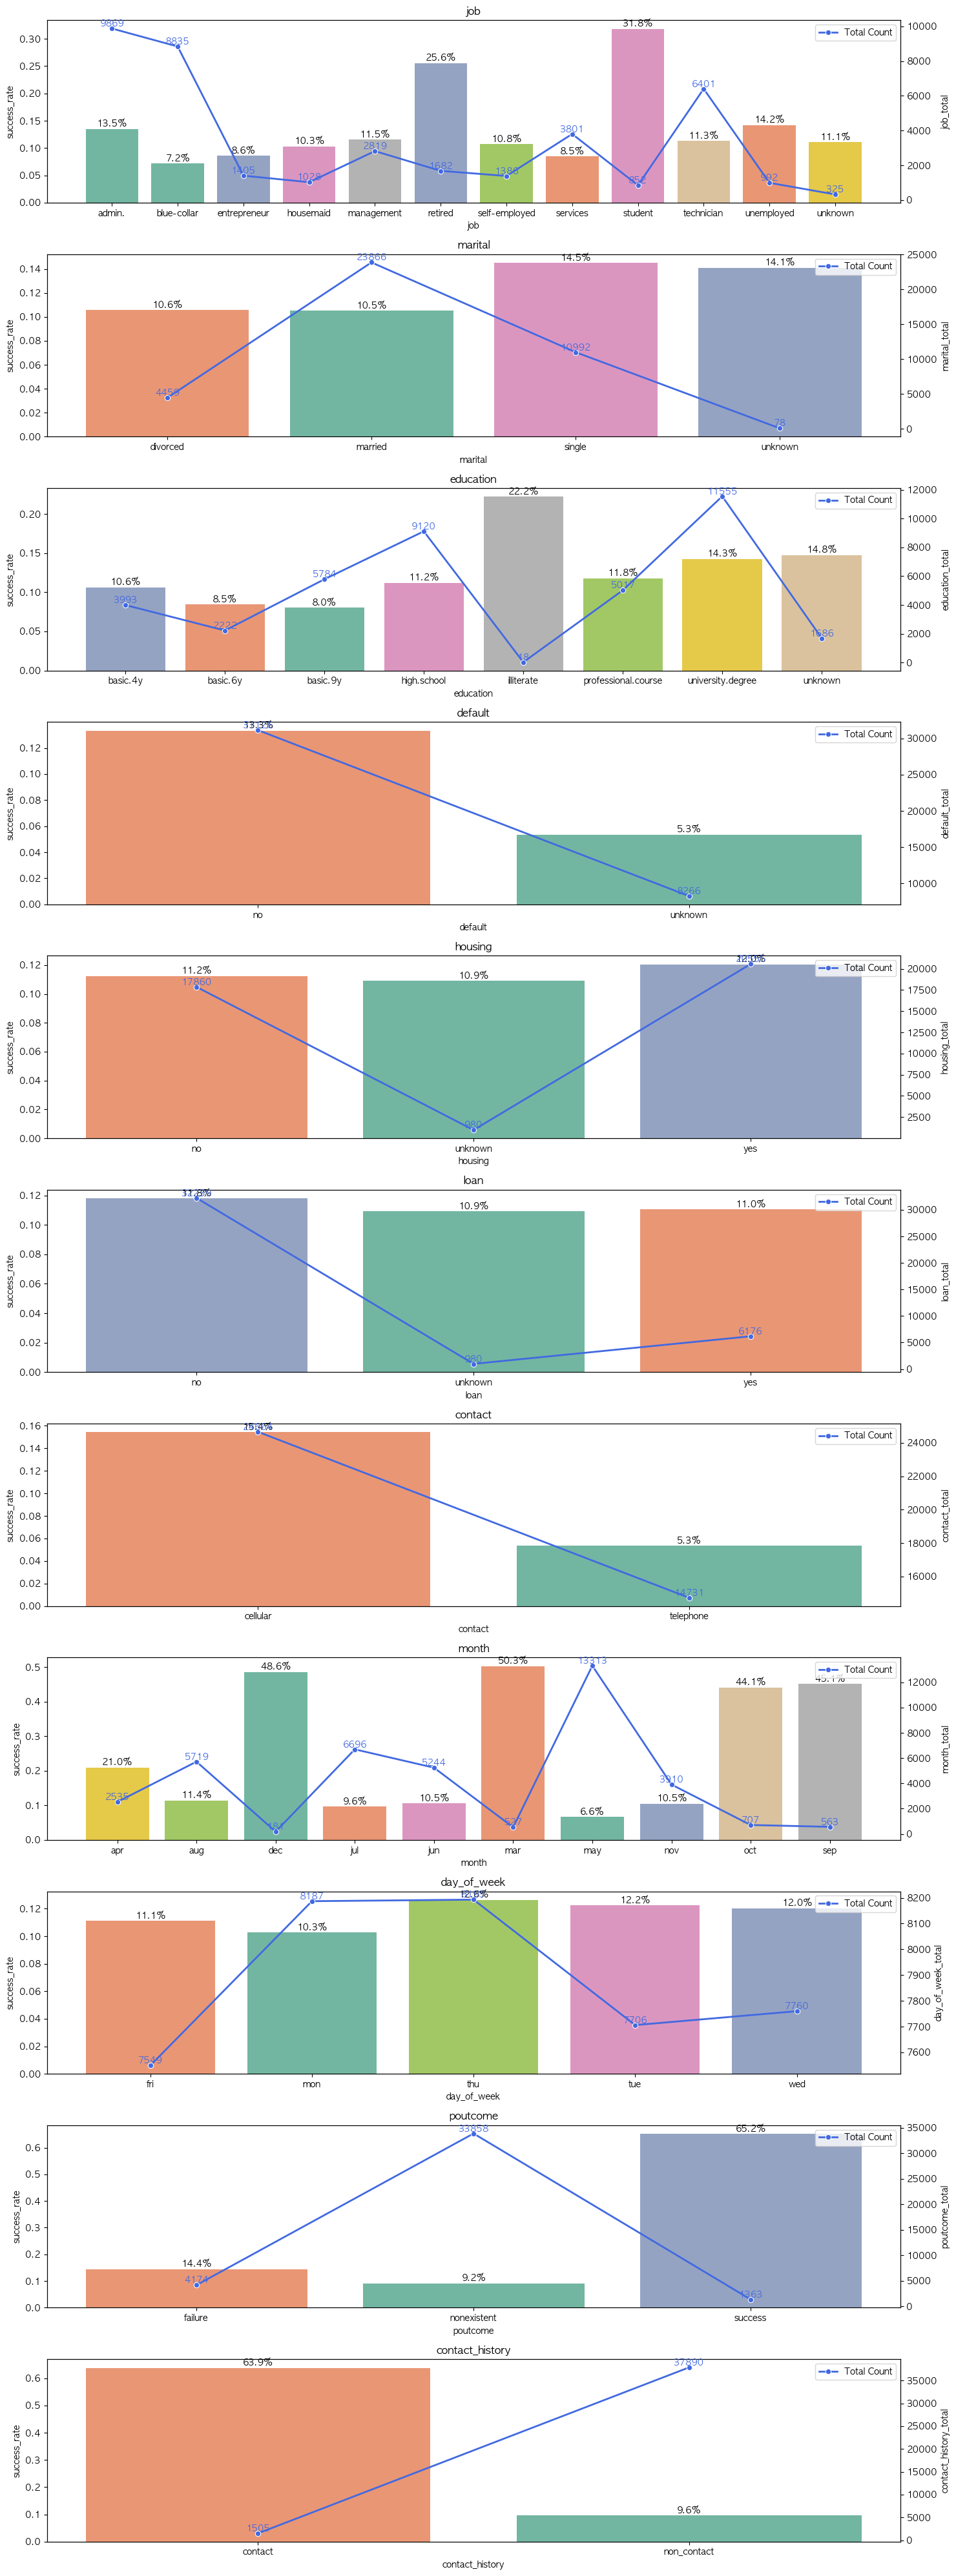

In [21]:
fig, axes = plt.subplots(11, 1, figsize=(15,40))  
axes = axes.flatten()

for ax, categorical in zip(axes, categorical_list):
    bank_df_eda = bank_df.copy()
    count_df = bank_df_eda.groupby([categorical, "y"]).size().reset_index(name='count')
    count_df[f"{categorical}_total"] = count_df.groupby(categorical)["count"].transform("sum")
    count_df["success_rate"] = count_df["count"] / count_df[f"{categorical}_total"]
    count_df = count_df[count_df["y"] == "yes"]
    
    sns.barplot(count_df, x=categorical, y="success_rate",hue="success_rate", legend=False, palette="Set2", ax=ax)
    ax.set_title(categorical)

    ax2 = ax.twinx()  # 보조 축 생성
    sns.lineplot(data=count_df, x=categorical, y=f"{categorical}_total", 
                 color="royalblue", marker="o", linewidth=2, ax=ax2, label="Total Count")
    
    for c in ax.containers:
        ax.bar_label(c, fmt='{:.1%}'); 

    for i, val in enumerate(count_df[f"{categorical}_total"]):
        ax2.text(i, val, f'{val}', 
                 color="royalblue", 
                 fontweight='bold',
                 va='bottom',   # 텍스트 세로 정렬 (점 위: bottom, 점 아래: top)
                 ha='center')


plt.tight_layout()
plt.show()






## 모델링

In [22]:
X = bank_df.drop(['y'], axis=1)
y = bank_df['y']

In [23]:
bank_df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,contact_history
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,non_contact
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,non_contact
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,non_contact
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,non_contact
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,non_contact
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,1,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes,non_contact
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,1,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no,non_contact
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,2,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no,non_contact
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,1,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes,non_contact


In [24]:
pd.get_dummies(X, columns=categorical_list, dtype="int")

,age,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_admin.,job_blue-collar,...,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,contact_history_contact,contact_history_non_contact
0,56,1,0,1.1,93.994,-36.4,4.857,5191.0,0,0,...,0,1,0,0,0,0,1,0,0,1
1,57,1,0,1.1,93.994,-36.4,4.857,5191.0,0,0,...,0,1,0,0,0,0,1,0,0,1
2,37,1,0,1.1,93.994,-36.4,4.857,5191.0,0,0,...,0,1,0,0,0,0,1,0,0,1
3,40,1,0,1.1,93.994,-36.4,4.857,5191.0,1,0,...,0,1,0,0,0,0,1,0,0,1
4,56,1,0,1.1,93.994,-36.4,4.857,5191.0,0,0,...,0,1,0,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,1,0,-1.1,94.767,-50.8,1.028,4963.6,0,0,...,1,0,0,0,0,0,1,0,0,1
41184,46,1,0,-1.1,94.767,-50.8,1.028,4963.6,0,1,...,1,0,0,0,0,0,1,0,0,1
41185,56,2,0,-1.1,94.767,-50.8,1.028,4963.6,0,0,...,1,0,0,0,0,0,1,0,0,1
41186,44,1,0,-1.1,94.767,-50.8,1.028,4963.6,0,0,...,1,0,0,0,0,0,1,0,0,1


In [25]:
categorical_list

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'poutcome',
 'contact_history']

In [26]:
y = y.apply(lambda x: 1 if x == 'yes' else 0)  
y

0        0
1        0
2        0
3        0
4        0
        ..
41183    1
41184    0
41185    0
41186    1
41187    0
Name: y, Length: 39395, dtype: int64

In [29]:
X["contact"] = X["contact"].apply(lambda x: 1 if x =="cellular" else 0)

In [30]:
categorical_list = X.select_dtypes(include="object").columns.tolist()  

In [33]:
X = pd.get_dummies(X, columns=categorical_list, dtype='int')  

KeyError: "None of [Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'month',\n       'day_of_week', 'poutcome', 'contact_history'],\n      dtype='object')] are in the [columns]"

X

In [34]:
X

,age,contact,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_admin.,...,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,contact_history_contact,contact_history_non_contact
0,56,0,1,0,1.1,93.994,-36.4,4.857,5191.0,0,...,0,1,0,0,0,0,1,0,0,1
1,57,0,1,0,1.1,93.994,-36.4,4.857,5191.0,0,...,0,1,0,0,0,0,1,0,0,1
2,37,0,1,0,1.1,93.994,-36.4,4.857,5191.0,0,...,0,1,0,0,0,0,1,0,0,1
3,40,0,1,0,1.1,93.994,-36.4,4.857,5191.0,1,...,0,1,0,0,0,0,1,0,0,1
4,56,0,1,0,1.1,93.994,-36.4,4.857,5191.0,0,...,0,1,0,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,1,1,0,-1.1,94.767,-50.8,1.028,4963.6,0,...,1,0,0,0,0,0,1,0,0,1
41184,46,1,1,0,-1.1,94.767,-50.8,1.028,4963.6,0,...,1,0,0,0,0,0,1,0,0,1
41185,56,1,2,0,-1.1,94.767,-50.8,1.028,4963.6,0,...,1,0,0,0,0,0,1,0,0,1
41186,44,1,1,0,-1.1,94.767,-50.8,1.028,4963.6,0,...,1,0,0,0,0,0,1,0,0,1


In [38]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=40)  

In [39]:
randomforest_model = RandomForestClassifier(random_state=40) 

randomforest_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [40]:
y_pred_test = randomforest_model.predict(X_test)
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94      6934
           1       0.52      0.28      0.36       945

    accuracy                           0.88      7879
   macro avg       0.71      0.62      0.65      7879
weighted avg       0.86      0.88      0.87      7879



In [42]:
from sklearn.model_selection import GridSearchCV

randomforest_model = RandomForestClassifier(random_state=40) 

rf_params = {
    "n_estimators": [100, 200],  
    "max_depth": [None, 10, 20],  
    "class_weight": [None, "balanced", "balanced_subsample"] 
}

gridsearch_random_forest_model = GridSearchCV(
    randomforest_model,
    rf_params,
    scoring="f1",
    cv=5
)

gridsearch_random_forest_model.fit(X_train, y_train)

print('최적 하이퍼파라미터 :', gridsearch_random_forest_model.best_params_)

최적 하이퍼파라미터 : {'class_weight': 'balanced', 'max_depth': 10, 'n_estimators': 200}


In [43]:
y_pred_test = gridsearch_random_forest_model.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.94      0.88      0.91      6934
           1       0.40      0.60      0.48       945

    accuracy                           0.85      7879
   macro avg       0.67      0.74      0.70      7879
weighted avg       0.88      0.85      0.86      7879

